In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


## Imports & Data Loading

In [2]:
X_train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

In [3]:
X_test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

## Exploratory Data Analysis

In [4]:
X_train.shape

(198000, 15)

In [5]:
X_test.shape

(102000, 14)

In [6]:
X_train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
X_train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [8]:
X_train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

In [9]:
X_train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [11]:
cat_columns=X_train.select_dtypes(include=object).columns
num_columns=X_train.select_dtypes(include=np.number).columns
bool_columns=X_train.select_dtypes(include=bool).columns

num_columns=num_columns.drop('label')
num_columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2'],
      dtype='object')

In [12]:
for col in cat_columns:
    print(X_train[col].value_counts(normalize=True))

created_date
2022-05-06 20:47:06.726636+00:00    0.000010
2022-04-29 22:21:30.915678+00:00    0.000010
2022-05-06 22:02:26.533945+00:00    0.000010
2022-04-29 21:54:28.400339+00:00    0.000010
2024-04-05 01:57:36.937249+00:00    0.000005
                                      ...   
2024-01-29 01:47:02.047744+00:00    0.000005
2023-09-01 10:04:57.674279+00:00    0.000005
2024-04-16 02:02:10.980708+00:00    0.000005
2024-01-11 01:19:01.457390+00:00    0.000005
2023-09-02 19:11:55.487975+00:00    0.000005
Name: proportion, Length: 197996, dtype: float64
race
none      0.754741
white     0.104342
black     0.073587
other     0.031459
asian     0.024022
latino    0.011849
Name: proportion, dtype: float64
religion
none         0.727485
christian    0.136771
muslim       0.093767
jewish       0.023661
other        0.010404
atheist      0.004165
buddhist     0.001902
hindu        0.001845
Name: proportion, dtype: float64
gender
none           0.687772
female         0.152862
male           0.1

In [13]:
X_train[bool_columns].value_counts(normalize=True)

disability
False         0.986146
True          0.013854
Name: proportion, dtype: float64

In [14]:
X_train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [15]:
X_test.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [16]:
X_train[bool_columns].value_counts(normalize=True)

disability
False         0.986146
True          0.013854
Name: proportion, dtype: float64

### Imputation

In [17]:
for col in ['race','religion','gender']:
    X_test[col].fillna(X_train[col].mode()[0],inplace=True)

/tmp/ipykernel_24/2928279281.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test[col].fillna(X_train[col].mode()[0],inplace=True)


In [18]:
for col in ['race','religion','gender']:
    X_train[col].fillna(X_train[col].mode()[0],inplace=True)

/tmp/ipykernel_24/385987072.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(X_train[col].mode()[0],inplace=True)


In [19]:
X_train.dropna(subset=['comment'],inplace=True)

In [20]:
X_train.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
dtype: int64

In [21]:
X_test.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
dtype: int64

### Checking Duplicates

In [22]:
X_train.duplicated().sum()
X_test.duplicated().sum()

np.int64(0)

In [23]:
X_train.drop(['post_id'],axis=1,inplace=True)
cat_columns=cat_columns.drop(['created_date','comment'])
num_columns=list(num_columns.drop('post_id'))

In [24]:
y=X_train['label']
X=X_train.drop('label',axis=1)

## Data Visualisation

### Class Distribution (bar)
Confirms class imbalance — class 3 is ~2.7% of data, thus it will become the least captured, while class 0 be the most captured

<Axes: xlabel='label'>

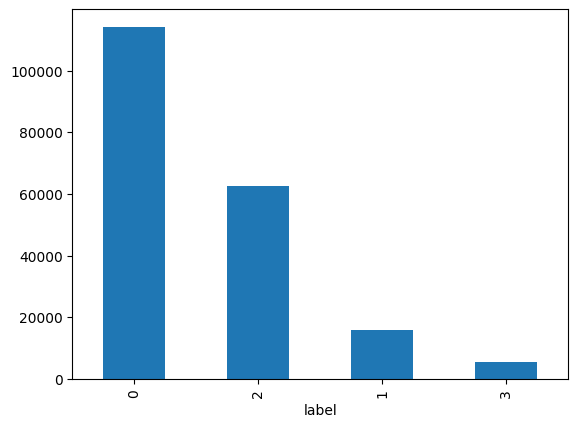

In [25]:
y.value_counts().plot(kind='bar')

### Boxplot
Checks for outliers in numeric features — upvote/downvote have extreme outliers justifying the PowerTransformer step. columns like if_1 and if_2 have severe outliers and this justifies due to the presence of extreme whole numbers.

<Axes: >

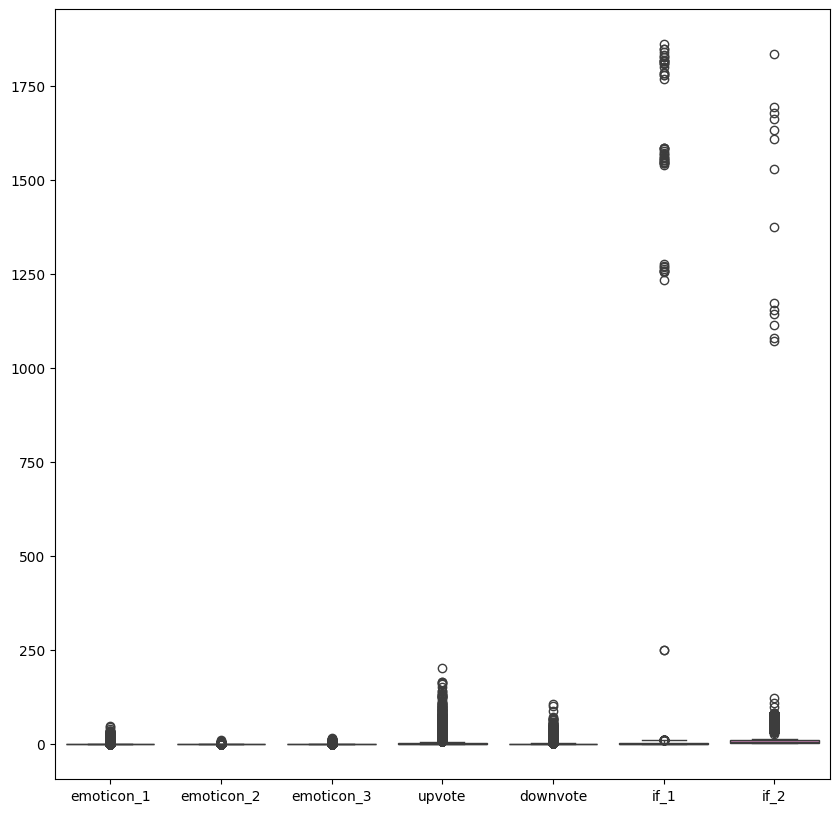

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.boxplot(X_train[['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']])

### Categorical bar chart with label

Checks if race/religion/gender correlate with toxicity class — if one category dominates a class it's a useful signal for the model.

from the bar chart its clear that None category dominates all the three columns - gender, race and religion.

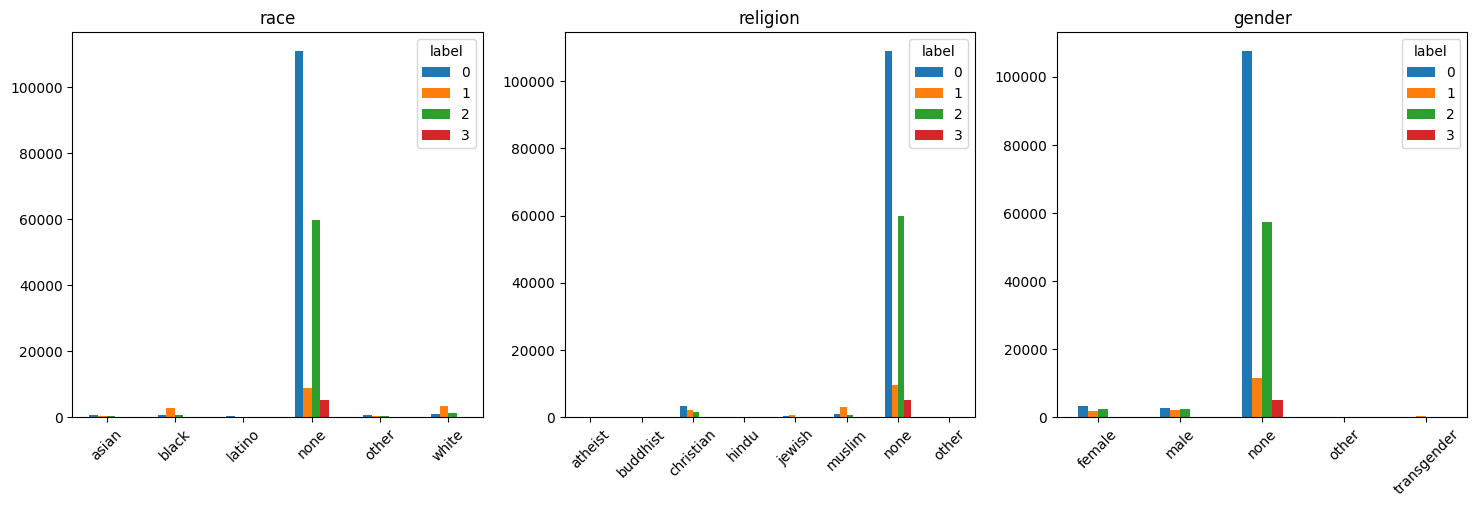

In [27]:
import math

cols = list(cat_columns)
n = len(cols)
ncols=3
nrows=math.ceil(n/ncols)

fig,axes=plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
axes=axes.flatten()

for i, col in enumerate(cols):
    X_train.groupby([col, 'label']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.show()

### Histplot with KDE
Shows distribution shape of skewed columns — confirms which ones need log/yeo-johnson transform before scaling.

columns like upvote, downvote, if_1, if_2 are nearly whole number values, while others have a continous distribution

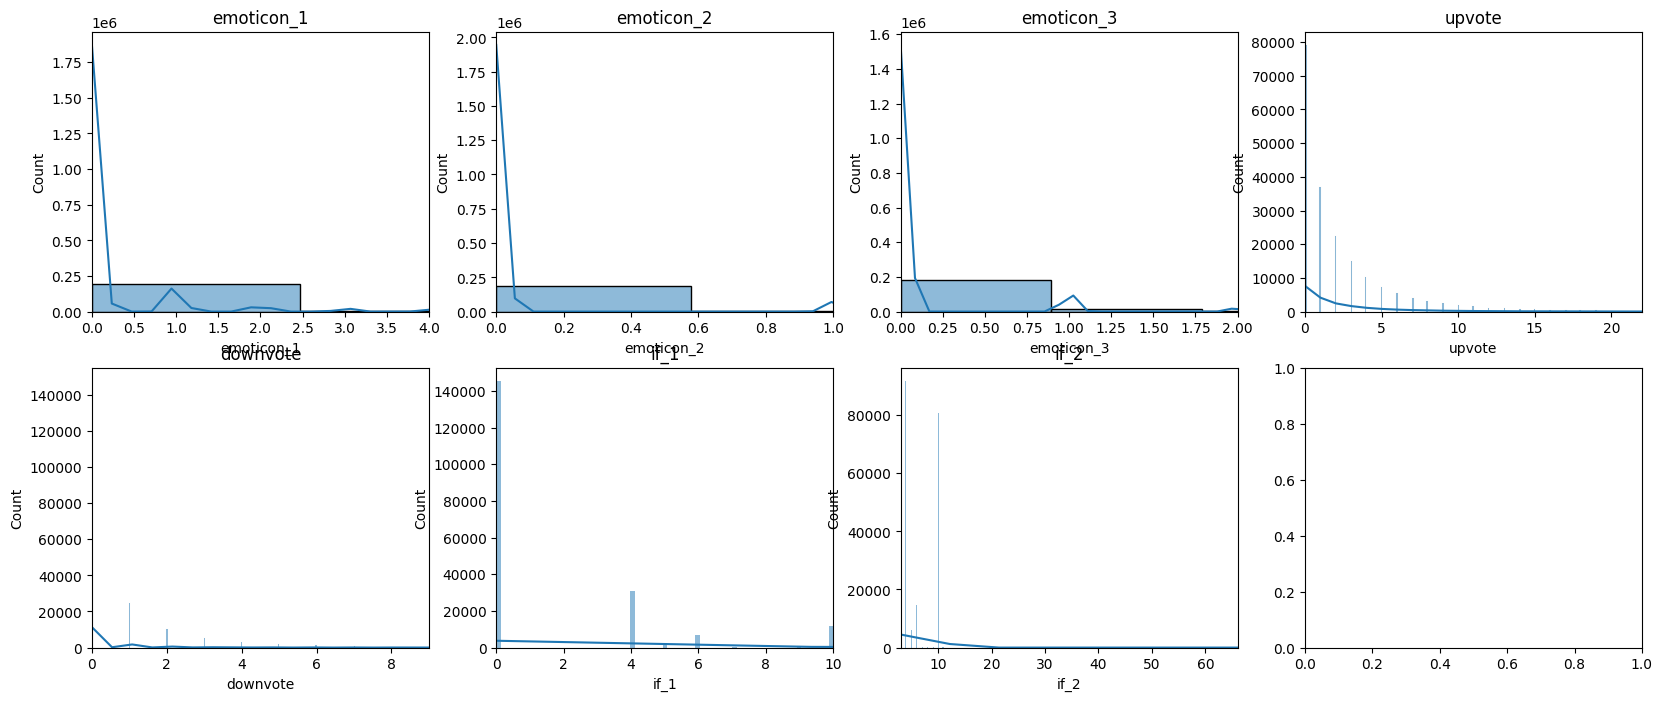

In [28]:
cols=['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']
n=len(cols)
ncols=4
nrows=math.ceil(n / ncols)

fig,axes=plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows*4))
axes=axes.flatten()

for i,col in enumerate(cols):
    sns.histplot(X_train[col],kde=True,ax=axes[i])
    axes[i].set_title(col)
    q99=X_train[col].quantile(0.99)
    axes[i].set_xlim(X_train[col].min(),q99)

plt.show()

### Correlation Heatmap
Shows multicollinearity between features — suppose if one feature has more colrrelation with other feature, one can be dropped to reduce noise in the feature matrix. But here, the correlation is not huge between any of the features.

In [29]:
#Correlation matrix
corr=X_train[['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']].corr()
corr

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
emoticon_1,1.000000,0.092087,0.144864,0.128124,0.177236,-0.002624,-0.004116
emoticon_2,0.092087,1.000000,0.140236,0.081579,0.169366,0.001741,0.003918
emoticon_3,0.144864,0.140236,1.000000,0.170662,0.371039,-0.000514,0.007191
upvote,0.128124,0.081579,0.170662,1.000000,0.314556,-0.001654,-0.000674
downvote,0.177236,0.169366,0.371039,0.314556,1.000000,0.000354,0.006306
if_1,-0.002624,0.001741,-0.000514,-0.001654,0.000354,1.000000,0.008174
if_2,-0.004116,0.003918,0.007191,-0.000674,0.006306,0.008174,1.000000


<Axes: >

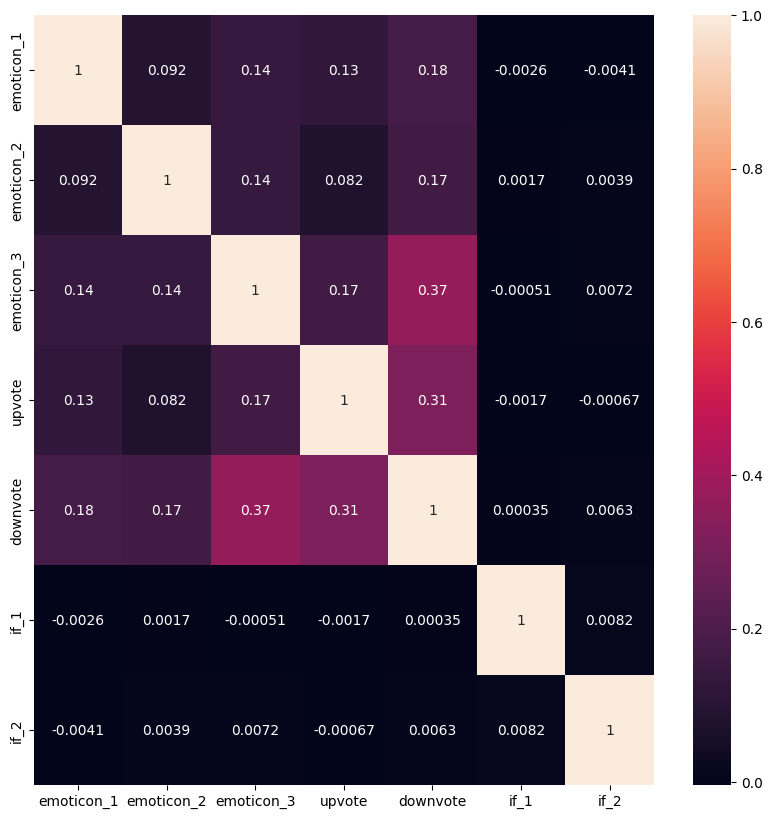

In [30]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)

### Feature Engineering

Datetime features (day, hour, weekday sin/cos) and vote-based features (total_votes, engagement_ratio, controversial_score) were extracted to capture temporal patterns and user engagement signals. Text-level features like caps_word_count, avg_word_length, unique_word_ratio, elongated_count and emoji_count were added to capture writing style indicators that correlate with toxicity.

Main aim is to increase class 3 weight/effect in the dataset.

In [31]:
X_train['created_date']=pd.to_datetime(X_train['created_date'])
X_test['created_date']=pd.to_datetime(X_test['created_date'])

In [32]:
X_train['year']=X_train['created_date'].dt.year
X_train['month']=X_train['created_date'].dt.month
X_train['day']=X_train['created_date'].dt.day
X_train['hour']=X_train['created_date'].dt.hour
X_train['day_of_week_num']=X_train['created_date'].dt.weekday 
X_train['weekday_sin'] = np.sin(2*np.pi*X_train['day_of_week_num']/7)
X_train['weekday_cos'] = np.cos(2*np.pi*X_train['day_of_week_num']/7)
X_train['hour_sin'] = np.sin(2*np.pi*X_train['hour']/24)
X_train['hour_cos'] = np.cos(2*np.pi*X_train['hour']/24)

In [33]:
X_test['year']=X_test['created_date'].dt.year
X_test['month']=X_test['created_date'].dt.month
X_test['day']=X_test['created_date'].dt.day
X_test['hour']=X_test['created_date'].dt.hour
X_test['day_of_week_num']=X_test['created_date'].dt.weekday 
X_test['weekday_sin'] = np.sin(2*np.pi*X_test['day_of_week_num']/7)
X_test['weekday_cos'] = np.cos(2*np.pi*X_test['day_of_week_num']/7)
X_test['hour_sin'] = np.sin(2*np.pi*X_test['hour']/24)
X_test['hour_cos'] = np.cos(2*np.pi*X_test['hour']/24)

In [34]:
X_train['total_votes']=X_train['upvote']+X_train['downvote']
X_train['net_votes']=X_train['upvote']-X_train['downvote']
X_train['engagement_ratio']=X_train['upvote']/(X_train['total_votes']+1)
X_train['controversial_score']=np.minimum(X_train['upvote'],X_train['downvote'])

In [35]:
X_test['total_votes']=X_test['upvote']+X_test['downvote']
X_test['net_votes']=X_test['upvote']-X_test['downvote']
X_test['engagement_ratio']=X_test['upvote']/(X_test['total_votes']+1)
X_test['controversial_score']=np.minimum(X_test['upvote'],X_test['downvote'])

In [36]:
X_train["emoticon_total"] = (X_train["emoticon_1"] +X_train["emoticon_2"] +X_train["emoticon_3"])
X_train['emoticon_presence']=((X_train["emoticon_1"] +X_train["emoticon_2"] +X_train["emoticon_3"])>0).astype(int)
X_train['dominant']=X_train[["emoticon_1","emoticon_2","emoticon_3"]].idxmax(axis=1)
X_train.loc[X_train["emoticon_total"] == 0, "dominant"] = 0

X_train["dominant"] = X_train["dominant"].map({
    "emoticon_1": 1,
    "emoticon_2": 2,
    "emoticon_3": 3,
    0: 0
})

In [37]:
X_test["emoticon_total"] = (X_test["emoticon_1"] +X_test["emoticon_2"] +X_test["emoticon_3"])
X_test['emoticon_presence']=((X_test["emoticon_1"] +X_test["emoticon_2"] +X_test["emoticon_3"])>0).astype(int)
X_test['dominant']=X_test[["emoticon_1","emoticon_2","emoticon_3"]].idxmax(axis=1)
X_test.loc[X_test["emoticon_total"] == 0, "dominant"] = 0

X_test["dominant"] = X_test["dominant"].map({
    "emoticon_1": 1,
    "emoticon_2": 2,
    "emoticon_3": 3,
    0: 0
})

In [38]:
import re

def add_emotion_features_inplace(df, text_col):
    
    text_series = df[text_col].astype(str)
    
    # Length
    df['char_count'] = text_series.apply(len)
    df['word_count'] = text_series.apply(lambda x: len(x.split()))
    
    # Punctuation
    df['exclamation_count'] = text_series.str.count('!')
    df['question_count'] = text_series.str.count(r'\?')
    
    # Uppercase ratio
    df['upper_ratio'] = text_series.apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
    )
    
    # Elongated words (soooo, noooo)
    df['elongated_count'] = text_series.apply(
        lambda x: len(re.findall(r'(.)\1{2,}', x))
    )
    
    # Emoji count
    df['emoji_count'] = text_series.apply(
        lambda x: len(re.findall(r'[\U0001F600-\U0001F64F]', x))
    )
    
    # Simple emotion lexicon flags
    positive_words = ['happy', 'love', 'great', 'awesome', 'amazing']
    negative_words = ['sad', 'angry', 'hate', 'worst', 'bad']
    
    df['positive_word_flag'] = text_series.apply(
        lambda x: int(any(word in x.lower() for word in positive_words))
    )
    
    df['negative_word_flag'] = text_series.apply(
        lambda x: int(any(word in x.lower() for word in negative_words))
    )

In [39]:
add_emotion_features_inplace(X_train, 'comment')
add_emotion_features_inplace(X_test,'comment')

comment text cleaning

In [40]:
import re
def clean_comment(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   
    text = re.sub(r'@\w+', '', text)          
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) 
    text = re.sub(r'[^a-z\s!?]', ' ', text)
    return text.strip()

X_train['comment']=X_train['comment'].apply(clean_comment)
X_test['comment']=X_test['comment'].apply(clean_comment)

In [41]:
num_columns.extend(['total_votes','net_votes','engagement_ratio','controversial_score','year','month','day','hour','day_of_week_num','weekday_sin','weekday_cos','hour_sin','hour_cos','char_count',
    'word_count',
    'exclamation_count',
    'question_count',
    'upper_ratio',
    'elongated_count',
    'emoji_count',
    'positive_word_flag',
    'negative_word_flag','emoticon_total','emoticon_presence','dominant'])

Dropped original date column after extraction

In [42]:
X_train.drop('created_date',axis=1,inplace=True)

In [43]:
X_test.drop('created_date',axis=1,inplace=True)

checking class imbalance in split

In [44]:
y.value_counts(normalize=True)

label
0    0.576629
2    0.315355
1    0.080394
3    0.027621
Name: proportion, dtype: float64

### Encoding
One Hot Encoding — categorical columns like race, religion, gender have no ordinal relationship so label encoding would imply false ordering, making OHE the correct choice.

In [45]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

### TF-IDF (word + char_wb)
word ngrams (1,3) capture phrase-level toxicity patterns while char_wb ngrams (3,5) capture subword patterns like slurs, misspellings and character repetitions that are common in toxic comments.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf=TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_features=25000,sublinear_tf=True,min_df=10,max_df=0.8)
tfidf_char=TfidfVectorizer(analyzer='char',ngram_range=(3,5),min_df=10,max_features=25000,sublinear_tf=True)

In [47]:
from sklearn.compose import ColumnTransformer

cat_transformers=[('ohe',ohe,cat_columns),('tfidf',tfidf,'comment'),('tfidf_char',tfidf_char,'comment')]
cat_transformer=ColumnTransformer(transformers=cat_transformers,n_jobs=-1)

### Transformation
skewed numeric features violate the normality assumption of linear models like SGD, so Yeo-Johnson transform is applied to make distributions more symmetric.

In [48]:
X_train[num_columns].skew()

emoticon_1              9.980202
emoticon_2              7.557428
emoticon_3              7.060189
upvote                  7.102903
downvote               10.062464
if_1                   63.702293
if_2                   67.321062
total_votes             6.830799
net_votes               5.920304
engagement_ratio        0.072959
controversial_score     9.658335
year                   -0.303064
month                   0.275969
day                     0.018535
hour                   -0.119929
day_of_week_num        -0.066660
weekday_sin             0.111715
weekday_cos            -0.066485
hour_sin                0.151979
hour_cos               -0.648023
char_count              1.226323
word_count              1.230847
exclamation_count      23.076152
question_count          5.652704
upper_ratio             9.450569
elongated_count        26.832362
emoji_count            60.536270
positive_word_flag      3.437915
negative_word_flag      2.877116
emoticon_total          7.663973
emoticon_p

In [49]:
skewed_columns=[k for k in X_train[num_columns] if abs(X_train[k].skew())>1]
skewed_columns

['emoticon_1',
 'emoticon_2',
 'emoticon_3',
 'upvote',
 'downvote',
 'if_1',
 'if_2',
 'total_votes',
 'net_votes',
 'controversial_score',
 'char_count',
 'word_count',
 'exclamation_count',
 'question_count',
 'upper_ratio',
 'elongated_count',
 'emoji_count',
 'positive_word_flag',
 'negative_word_flag',
 'emoticon_total',
 'emoticon_presence',
 'dominant']

In [50]:
skewed={'neg':[],'pos':[],'zero':[]}
for col in skewed_columns:
    if (X_train[col]<0).any():
        skewed['neg'].append(col)
    elif (X_train[col]>0).any():
        skewed['pos'].append(col)
    else:
        skewed['zero'].append(col)
skewed
        

{'neg': ['net_votes'],
 'pos': ['emoticon_1',
  'emoticon_2',
  'emoticon_3',
  'upvote',
  'downvote',
  'if_1',
  'if_2',
  'total_votes',
  'controversial_score',
  'char_count',
  'word_count',
  'exclamation_count',
  'question_count',
  'upper_ratio',
  'elongated_count',
  'emoji_count',
  'positive_word_flag',
  'negative_word_flag',
  'emoticon_total',
  'emoticon_presence',
  'dominant'],
 'zero': []}

Power transformer

In [51]:
from sklearn.preprocessing import PowerTransformer

ptr=PowerTransformer(method='yeo-johnson')
cols = skewed['pos'] + skewed['neg']

log transform

In [52]:
def log_transform(X):
    return np.log1p(X)

Concatenation of numerical set

In [53]:
from sklearn.preprocessing import FunctionTransformer

log_1p=FunctionTransformer(log_transform)

In [54]:
from sklearn.compose import ColumnTransformer

num_transformers=[("zero",log_1p,skewed['zero']),("other",ptr,cols)]
num_transform=ColumnTransformer(transformers=num_transformers,remainder='passthrough',n_jobs=-1)

### Standard Scaling
brings all numeric features to the same scale so no single feature dominates the sparse TF-IDF matrix during SGD optimization, though useless for tree models.$

In [55]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

### Conversion to CSR Matrix
the final sets are converted to csr matrices and converted to float32 to prevent kernel crashes and memory optimization.

In [56]:
from sklearn.pipeline import Pipeline

num_pln=Pipeline([("transformer",num_transform),("scaler",ss)])

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

transformers=[('cat',cat_transformer,list(cat_columns)+['comment']),('num',num_pln,num_columns)]
final_pipeline=ColumnTransformer(transformers=transformers,n_jobs=-1)

final_train=final_pipeline.fit_transform(X_train)
final_test=final_pipeline.transform(X_test)

### TRAIN VAL SPLIT

In [58]:
from sklearn.model_selection import train_test_split
x_tr,x_val,y_tr,y_val=train_test_split(final_train,y,stratify=y,test_size=0.3,random_state=12)

## MODEL TRAINING AND TUNING

SGD (log_loss) — fast linear classifier on sparse TF-IDF matrix with elasticnet regularization and adaptive learning rate, class weights boosted for minority class 3.

Automated Tuning done with randomized search CV.## 

In [59]:
"""from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
import numpy as np

sgd=SGDClassifier(loss='log_loss', random_state=42)

params={
    'max_iter':[1000],
    'tol':[1e-4],
    'penalty':['elasticnet'],
    'learning_rate':['adaptive'],
    'alpha':[6e-6,7e-6,5e-6],
    'eta0':[0.04,0.05,0.06],
    'l1_ratio':[0.83,0.85,0.87],
    'class_weight':[{0:1,1:2,2:1,3:3},{0:1,1:3,2:1,3:4},{0:1,1:2,2:1,3:4},{0:1,1:3,2:1,3:5}]}
    
skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
rs=RandomizedSearchCV(estimator=sgd,param_distributions=params,n_iter=20,cv=skf,scoring='f1_macro',n_jobs=-1,verbose=2,random_state=42)

rs.fit(final_train,y_train)
print("Best params:",rs.best_params_)
print("Best F1:",rs.best_score_)"""

'from sklearn.linear_model import SGDClassifier\nfrom sklearn.model_selection import RandomizedSearchCV,StratifiedKFold\nimport numpy as np\n\nsgd=SGDClassifier(loss=\'log_loss\', random_state=42)\n\nparams={\n    \'max_iter\':[1000],\n    \'tol\':[1e-4],\n    \'penalty\':[\'elasticnet\'],\n    \'learning_rate\':[\'adaptive\'],\n    \'alpha\':[6e-6,7e-6,5e-6],\n    \'eta0\':[0.04,0.05,0.06],\n    \'l1_ratio\':[0.83,0.85,0.87],\n    \'class_weight\':[{0:1,1:2,2:1,3:3},{0:1,1:3,2:1,3:4},{0:1,1:2,2:1,3:4},{0:1,1:3,2:1,3:5}]}\n    \nskf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)\nrs=RandomizedSearchCV(estimator=sgd,param_distributions=params,n_iter=20,cv=skf,scoring=\'f1_macro\',n_jobs=-1,verbose=2,random_state=42)\n\nrs.fit(final_train,y_train)\nprint("Best params:",rs.best_params_)\nprint("Best F1:",rs.best_score_)'

best params used.

In [60]:
from sklearn.linear_model import SGDClassifier
sgd=SGDClassifier(max_iter=1000,random_state=42,tol=1e-4,loss='log_loss',class_weight={0:1,1:3,2:1,3:4},learning_rate='adaptive',eta0=0.03,penalty='elasticnet',alpha=7e-6,l1_ratio=0.83)
sgd.fit(x_tr,y_tr)

SGDClassifier(alpha=7e-06, class_weight={0: 1, 1: 3, 2: 1, 3: 4}, eta0=0.03,
              l1_ratio=0.83, learning_rate='adaptive', loss='log_loss',
              penalty='elasticnet', random_state=42, tol=0.0001)

In [61]:
final_train.dtype

dtype('float64')

Threshold Tuning — default 0.5 threshold is suboptimal under class imbalance so per-class thresholds are tuned by maximizing F1 on the precision-recall curve.

In [62]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score

log_proba_val=sgd.predict_proba(x_val)
log_proba_test=sgd.predict_proba(final_test)
n_classes=log_proba_val.shape[1]
thresholds=[]

for class_idx in range(n_classes):
    y_true_class=(y_val==class_idx).astype(int)
    y_scores_class=log_proba_val[:,class_idx]
    
    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)
    f1_scores=2*precision*recall/(precision+recall+1e-6)
    f1_scores=f1_scores[:-1]
    
    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5
    thresholds.append(best_thresh)

print("F1-optimal thresholds per class:",thresholds)
adjusted_val=log_proba_val/np.array(thresholds)
adjusted_test=log_proba_test/np.array(thresholds)
y_pred_val_sgd=np.argmax(adjusted_val,axis=1)
y_pred=np.argmax(adjusted_test,axis=1)
print(classification_report(y_val,y_pred_val_sgd,digits=2))
print("Macro F1 on val:",f1_score(y_val,y_pred_val_sgd,average='macro'))

F1-optimal thresholds per class: [np.float64(0.40426082557567056), np.float64(0.4422052466822149), np.float64(0.43474588380645585), np.float64(0.3826617378536264)]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     34252
           1       0.76      0.82      0.79      4775
           2       0.87      0.90      0.89     18732
           3       0.66      0.70      0.68      1641

    accuracy                           0.91     59400
   macro avg       0.82      0.84      0.83     59400
weighted avg       0.92      0.91      0.91     59400

Macro F1 on val: 0.8284459748719977


ComplementNB (text only) — trained only on TF-IDF columns since Naive Bayes assumes feature independence which holds better for text than mixed numeric/categorical features.

In [63]:
"""from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

params={
    'alpha':[0.01,0.1,0.5,1,2,5,10],
    'norm':[True,False]
}

skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)

grid=GridSearchCV(estimator=ComplementNB(),param_grid=params,cv=skf,scoring='f1_macro',n_jobs=-1,verbose=2)

grid.fit(final_train.tocsr()[:,61:],y_train)
print("Best params:",grid.best_params_)
print("Best F1:",grid.best_score_)"""

'from sklearn.naive_bayes import ComplementNB\nfrom sklearn.model_selection import GridSearchCV, StratifiedKFold\n\nparams={\n    \'alpha\':[0.01,0.1,0.5,1,2,5,10],\n    \'norm\':[True,False]\n}\n\nskf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)\n\ngrid=GridSearchCV(estimator=ComplementNB(),param_grid=params,cv=skf,scoring=\'f1_macro\',n_jobs=-1,verbose=2)\n\ngrid.fit(final_train.tocsr()[:,61:],y_train)\nprint("Best params:",grid.best_params_)\nprint("Best F1:",grid.best_score_)'

final good params used.

In [64]:
from sklearn.naive_bayes import ComplementNB

cnb=ComplementNB(alpha=2)
cnb.fit(x_tr.tocsr()[:,19:25019], y_tr)

ComplementNB(alpha=2)

Threshold Tuning — default 0.5 threshold is suboptimal under class imbalance so per-class thresholds are tuned by maximizing F1 on the precision-recall curve.

In [65]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score

cnb_proba_val=cnb.predict_proba(x_val.tocsr()[:,19:25019])
cnb_proba_test=cnb.predict_proba(final_test.tocsr()[:,19:25019])
n_classes=cnb_proba_val.shape[1]
thresholds=[]

for class_idx in range(n_classes):
    y_true_class=(y_val==class_idx).astype(int)
    y_scores_class=cnb_proba_val[:,class_idx]
    
    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)
    f1_scores=2*precision*recall/(precision+recall+1e-6)
    f1_scores=f1_scores[:-1]
    
    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5
    thresholds.append(best_thresh)

print("F1-optimal thresholds per class:",thresholds)
adjusted_val=cnb_proba_val/np.array(thresholds)
adjusted_test=cnb_proba_test/np.array(thresholds)
y_pred_val_cnb=np.argmax(adjusted_val,axis=1)
y_pred=np.argmax(adjusted_test,axis=1)
print(classification_report(y_val,y_pred_val_cnb,digits=2))
print("Macro F1 on val:",f1_score(y_val,y_pred_val_cnb,average='macro'))

F1-optimal thresholds per class: [np.float64(0.20970664765238664), np.float64(0.31498920737885816), np.float64(0.27274107598995945), np.float64(0.27396032482200106)]
              precision    recall  f1-score   support

           0       0.76      0.86      0.81     34252
           1       0.65      0.64      0.64      4775
           2       0.71      0.59      0.65     18732
           3       0.53      0.28      0.37      1641

    accuracy                           0.74     59400
   macro avg       0.66      0.59      0.61     59400
weighted avg       0.73      0.74      0.73     59400

Macro F1 on val: 0.6148943952770304


XGBoost — gradient boosted trees with histogram method and sample weights to handle imbalance, captures non-linear interactions between numeric and encoded features.

Tuned Manually as automated tuning can be exhaustive. Also commenting now to reduce runtime as the model didnt contribute for final stack.

In [66]:
"""from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=400,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,colsample_bylevel=0.7,
    tree_method='hist',device='cuda',
    random_state=42,reg_lambda=1.5,
    n_jobs=1,min_child_weight=10,reg_alpha=0.1,gamma=0.1,max_delta_step=1,colsample_bynode=0.7,
    eval_metric='mlogloss',max_bin=128,sampling_method='gradient_based'
)
class_weights={0:1,1:2,2:1,3:3}
sample_weights = [class_weights[y] for y in y_tr]
xgb.fit(
    x_tr, y_tr,sample_weight=sample_weights)  """

"from xgboost import XGBClassifier\nfrom sklearn.utils.class_weight import compute_sample_weight\n\nxgb = XGBClassifier(\n    objective='multi:softprob',\n    num_class=4,\n    n_estimators=400,\n    learning_rate=0.1,\n    max_depth=6,\n    subsample=0.8,\n    colsample_bytree=0.7,colsample_bylevel=0.7,\n    tree_method='hist',device='cuda',\n    random_state=42,reg_lambda=1.5,\n    n_jobs=1,min_child_weight=10,reg_alpha=0.1,gamma=0.1,max_delta_step=1,colsample_bynode=0.7,\n    eval_metric='mlogloss',max_bin=128,sampling_method='gradient_based'\n)\nclass_weights={0:1,1:2,2:1,3:3}\nsample_weights = [class_weights[y] for y in y_tr]\nxgb.fit(\n    x_tr, y_tr,sample_weight=sample_weights)  "

In [67]:
"""from sklearn.metrics import precision_recall_curve, classification_report, f1_score

xg_proba_val=xgb.predict_proba(x_val)
xg_proba_val[:,3]*=1
xg_proba_val/=xg_proba_val.sum(axis=1,keepdims=True)
xg_proba_test=xgb.predict_proba(test)

n_classes=xg_proba_val.shape[1]
thresholds=[]

for class_idx in range(n_classes):
    y_true_class=(y_val==class_idx).astype(int)
    y_scores_class=xg_proba_val[:,class_idx]
    
    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)
    f1_scores=2*precision*recall/(precision+recall+1e-6)
    f1_scores=f1_scores[:-1]
    
    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5
    thresholds.append(best_thresh)

print("F1-optimal thresholds per class:",thresholds)

adjusted_val=xg_proba_val/np.array(thresholds)
adjusted_test=xg_proba_test/np.array(thresholds)

y_pred_val_xg=np.argmax(adjusted_val,axis=1)
y_pred=np.argmax(adjusted_test,axis=1)

print(classification_report(y_val,y_pred_val_xg,digits=2))
print("Macro F1 on val:",f1_score(y_val,y_pred_val_xg,average='macro'))"""

'from sklearn.metrics import precision_recall_curve, classification_report, f1_score\n\nxg_proba_val=xgb.predict_proba(x_val)\nxg_proba_val[:,3]*=1\nxg_proba_val/=xg_proba_val.sum(axis=1,keepdims=True)\nxg_proba_test=xgb.predict_proba(test)\n\nn_classes=xg_proba_val.shape[1]\nthresholds=[]\n\nfor class_idx in range(n_classes):\n    y_true_class=(y_val==class_idx).astype(int)\n    y_scores_class=xg_proba_val[:,class_idx]\n    \n    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)\n    f1_scores=2*precision*recall/(precision+recall+1e-6)\n    f1_scores=f1_scores[:-1]\n    \n    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5\n    thresholds.append(best_thresh)\n\nprint("F1-optimal thresholds per class:",thresholds)\n\nadjusted_val=xg_proba_val/np.array(thresholds)\nadjusted_test=xg_proba_test/np.array(thresholds)\n\ny_pred_val_xg=np.argmax(adjusted_val,axis=1)\ny_pred=np.argmax(adjusted_test,axis=1)\n\nprint(classification_report(y_val,y_pred

### XGB Results
**Thresholds:** [0.4889, 0.4212, 0.3684, 0.3823] | **Accuracy:** 0.9134 | **Macro F1:** 0.8184

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0 | 0.9774 | 0.9474 | 0.9622 | 34252 |
| 1 | 0.7644 | 0.8111 | 0.7870 | 4775 |
| 2 | 0.8612 | 0.9040 | 0.8821 | 18732 |
| 3 | 0.6801 | 0.6088 | 0.6424 | 1641 |
| **macro avg** | **0.8208** | **0.8178** | **0.8184** | 59400 |
| weighted avg | 0.9154 | 0.9134 | 0.9140 | 59400 |

LightGBM — faster gradient boosting with leaf-wise growth, char_wb subword features and class weights, better handles the sparse high-dimensional feature matrix than XGBoost.

Tuned Manually as automated tuning can be exhaustive.

In [68]:
from lightgbm import LGBMClassifier
import lightgbm as lgb
lgbm=LGBMClassifier(objective='multiclass',num_class=4,class_weight={0:1,1:2,2:1,3:4},force_col_wise=True,max_depth=-1,num_leaves=255,max_bin=127,min_data_in_bin=10,colsample_bytree=0.4,
    subsample=0.55,subsample_freq=1,reg_lambda=1.5,reg_alpha=1, n_estimators=500,    
    learning_rate=0.05,min_split_gain=0.01,n_jobs=-1,device='gpu') 
lgbm.fit(x_tr, y_tr)                  


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2957007
[LightGBM] [Info] Number of data points in the train set: 138599, number of used features: 45484
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 87 dense feature groups (11.63 MB) transferred to GPU in 0.015339 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -0.701781
[LightGBM] [Info] Start training from score -1.978848
[LightGBM] [Info] Start training from score -1.305276
[LightGBM] [Info] Start training from score -2.354170
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

LGBMClassifier(class_weight={0: 1, 1: 2, 2: 1, 3: 4}, colsample_bytree=0.4,
               device='gpu', force_col_wise=True, learning_rate=0.05,
               max_bin=127, min_data_in_bin=10, min_split_gain=0.01,
               n_estimators=500, n_jobs=-1, num_class=4, num_leaves=255,
               objective='multiclass', reg_alpha=1, reg_lambda=1.5,
               subsample=0.55, subsample_freq=1)

Threshold Tuning — default 0.5 threshold is suboptimal under class imbalance so per-class thresholds are tuned by maximizing F1 on the precision-recall curve.

In [69]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score

lg_proba_val=lgbm.predict_proba(x_val)
lg_proba_test=lgbm.predict_proba(final_test)
n_classes=lg_proba_val.shape[1]
thresholds=[]

for class_idx in range(n_classes):
    y_true_class=(y_val==class_idx).astype(int)
    y_scores_class=lg_proba_val[:,class_idx]
    
    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)
    f1_scores=2*precision*recall/(precision+recall+1e-6)
    f1_scores=f1_scores[:-1]
    
    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5
    thresholds.append(best_thresh)

print("F1-optimal thresholds per class:",thresholds)
adjusted_val=lg_proba_val/np.array(thresholds)
adjusted_test=lg_proba_test/np.array(thresholds)
y_pred_val_lg=np.argmax(adjusted_val,axis=1)
y_pred=np.argmax(adjusted_test,axis=1)
print(classification_report(y_val,y_pred_val_lg,digits=2))
print("Macro F1 on val:",f1_score(y_val,y_pred_val_lg,average='macro'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-optimal thresholds per class: [np.float64(0.5884425347641061), np.float64(0.3855216001801828), np.float64(0.4733142629217537), np.float64(0.22676145931458846)]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     34252
           1       0.78      0.80      0.79      4775
           2       0.86      0.91      0.89     18732
           3       0.67      0.62      0.64      1641

    accuracy                           0.91     59400
   macro avg       0.82      0.82      0.82     59400
weighted avg       0.92      0.91      0.92     59400

Macro F1 on val: 0.8202447452592839


Stacking (MLP meta-learner) — probability outputs of SGD, LightGBM and CNB are stacked as meta-features and fed into a 2-layer MLP trained on the validation set, allowing the meta-learner to learn optimal model combination weights and predict on the test set.

In [70]:
from sklearn.neural_network import MLPClassifier

meta_train = np.hstack([log_proba_val,cnb_proba_val,lg_proba_val]) 
meta_test  = np.hstack([log_proba_test,cnb_proba_test,lg_proba_test])

meta_learner = MLPClassifier(hidden_layer_sizes=(256,256),alpha=1e-3,tol=1e-4,early_stopping=True,beta_1=0.9,beta_2=0.999,max_iter=500,random_state=42,activation='relu',solver='adam',learning_rate_init=0.001)
meta_learner.fit(meta_train, y_val)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(256, 256),
              max_iter=500, random_state=42)

In [71]:
mm_proba_val=meta_learner.predict_proba(meta_train)
mm_proba_test=meta_learner.predict_proba(meta_test)

from sklearn.metrics import precision_recall_curve, classification_report, f1_score

n_classes=mm_proba_val.shape[1]
thresholds=[]

for class_idx in range(n_classes):
    y_true_class=(y_val==class_idx).astype(int)
    y_scores_class=mm_proba_val[:,class_idx]
    
    precision,recall,thresh=precision_recall_curve(y_true_class,y_scores_class)
    f1_scores=2*precision*recall/(precision+recall+1e-6)
    f1_scores=f1_scores[:-1]
    
    best_thresh=thresh[np.argmax(f1_scores)] if len(thresh)>0 else 0.5
    thresholds.append(best_thresh)

print("F1-optimal thresholds per class:",thresholds)

adjusted_val=mm_proba_val/np.array(thresholds)
adjusted_test=mm_proba_test/np.array(thresholds)

y_pred_val_mm=np.argmax(adjusted_val,axis=1)
y_pred=np.argmax(adjusted_test,axis=1)

print(classification_report(y_val,y_pred_val_mm,digits=2))
print("Macro F1 on val:",f1_score(y_val,y_pred_val_mm,average='macro'))

F1-optimal thresholds per class: [np.float64(0.38767680525302944), np.float64(0.38964669051178763), np.float64(0.47901300922043344), np.float64(0.33658383884465876)]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     34252
           1       0.78      0.82      0.80      4775
           2       0.87      0.92      0.89     18732
           3       0.66      0.72      0.69      1641

    accuracy                           0.92     59400
   macro avg       0.83      0.85      0.84     59400
weighted avg       0.92      0.92      0.92     59400

Macro F1 on val: 0.8366309481768199


### FINAL MODEL COMPARISONS
Stacking model beats all other individual models as it combines the effects of all the models. Since XGBOOST is commented out, its scores are hardcoded into the table.

In [72]:
from sklearn.metrics import f1_score, precision_score, recall_score

models=['SGD','LGBM','CNB','Ensemble']
preds=[y_pred_val_sgd,y_pred_val_lg,y_pred_val_cnb,y_pred_val_mm]

results=[]
for name,pred in zip(models,preds):
    results.append({
        'model':name,
        'macro_f1':f1_score(y_val,pred,average='macro'),
        'weighted_f1':f1_score(y_val,pred,average='weighted'),
        'precision':precision_score(y_val,pred,average='macro'),
        'recall':recall_score(y_val,pred,average='macro')
    })

results.append({
    'model':'XGBoost',
    'macro_f1':0.8184,
    'weighted_f1':0.9140,
    'precision':0.8208,
    'recall':0.8178
})

df_results=pd.DataFrame(results).sort_values('macro_f1',ascending=False).reset_index(drop=True)
df_results

,model,macro_f1,weighted_f1,precision,recall
0,Ensemble,0.836631,0.920768,0.825479,0.848862
1,SGD,0.828446,0.914640,0.816819,0.841189
2,LGBM,0.820245,0.915330,0.822387,0.819226
3,XGBoost,0.818400,0.914000,0.820800,0.817800
4,CNB,0.614894,0.730441,0.663454,0.589951


### FINAL SUBMISSION

In [73]:
submission=pd.DataFrame({"ID":range(1,X_test.shape[0]+1),"target":y_pred})
submission.to_csv('submission.csv',index=False)